In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flow_rate       2000 non-null   float64
 1   pressure        2000 non-null   float64
 2   temperature     2000 non-null   float64
 3   usage_duration  2000 non-null   int64  
 4   vibration       2000 non-null   float64
 5   label           2000 non-null   str    
dtypes: float64(4), int64(1), str(1)
memory usage: 106.2 KB


In [9]:
df.describe()

,flow_rate,pressure,temperature,usage_duration,vibration
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,59.288685,270.611280,26.343235,80.707500,0.361190
std,24.739091,74.408853,3.645814,29.475895,0.268823
min,30.020000,100.710000,20.000000,30.000000,0.100000
25%,40.965000,207.005000,23.460000,56.000000,0.170000
50%,51.080000,300.395000,26.335000,79.500000,0.240000
75%,76.037500,325.482500,28.912500,104.000000,0.570000
max,119.950000,349.990000,34.990000,150.000000,1.000000


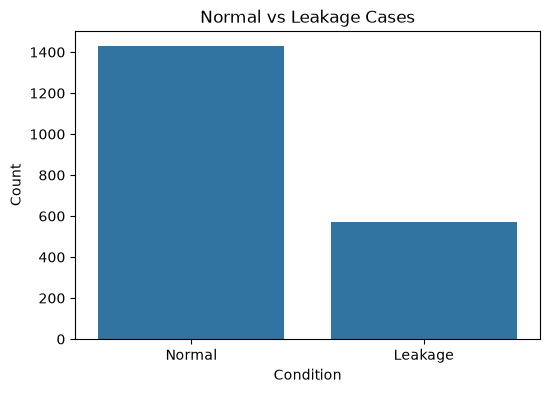

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Normal vs Leakage Cases")

plt.xlabel("Condition")

plt.ylabel("Count")

plt.show()

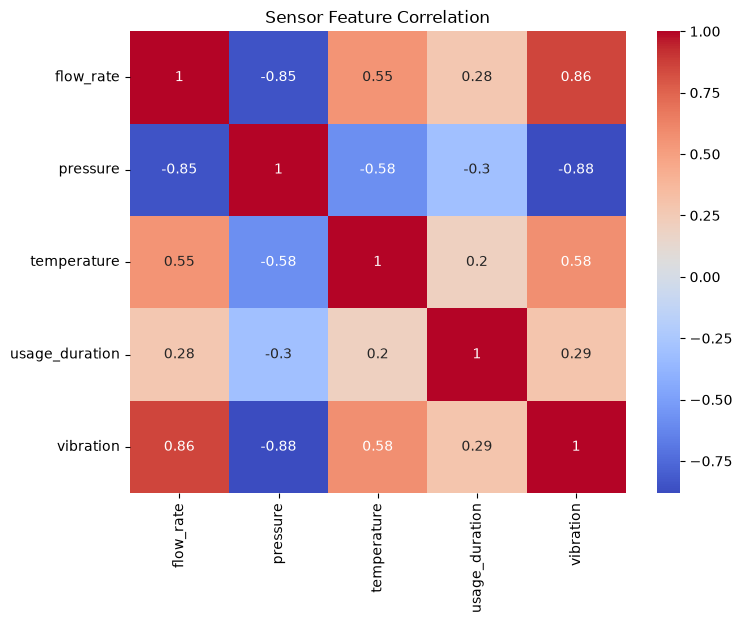

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Sensor Feature Correlation")

plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# copy dataset

data = df.copy()


# convert label

encoder = LabelEncoder()

data["label"] = encoder.fit_transform(
    data["label"]
)


data.head()

,flow_rate,pressure,temperature,usage_duration,vibration,label
0,53.89,326.02,24.64,94,0.19,1
1,84.42,118.97,31.68,97,0.56,0
2,32.66,322.02,20.77,84,0.20,1
3,71.75,109.17,28.00,83,0.64,0
4,33.46,326.95,22.49,56,0.12,1


In [13]:
from sklearn.model_selection import train_test_split


# Features and Target

X = data.drop(
    "label",
    axis=1
)


y = data["label"]



# Split dataset

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)



print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (1600, 5)
Testing Data: (400, 5)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# Create Model

model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)


# Train Model

model.fit(

    X_train,

    y_train

)



# Prediction

y_pred = model.predict(
    X_test
)



# Accuracy

accuracy = accuracy_score(

    y_test,

    y_pred

)



print(
    "Model Accuracy:",
    accuracy*100,
    "%"
)



print(
    classification_report(
        y_test,
        y_pred
    )
)

Model Accuracy: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00       297

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [15]:
import joblib
import os


# create models folder

os.makedirs(
    "../models",
    exist_ok=True
)


# save model

joblib.dump(
    model,
    "../models/leakage_model.pkl"
)


print("Model Saved Successfully")

Model Saved Successfully


In [6]:
import pandas as pd

df = pd.read_csv(
    "../ml/dataset/water_leakage_dataset.csv"
)

print(df.head())

   flow_rate  pressure  temperature  usage_duration  vibration    label
0      53.89    326.02        24.64              94       0.19   Normal
1      84.42    118.97        31.68              97       0.56  Leakage
2      32.66    322.02        20.77              84       0.20   Normal
3      71.75    109.17        28.00              83       0.64  Leakage
4      33.46    326.95        22.49              56       0.12   Normal
